# AF Futures ML Pipeline
Production-grade, scalable admission prediction pipeline.

Notebook structure:
1. Data loading and validation
2. Minimal EDA
3. Feature engineering and preprocessing
4. Model training
5. Hyperparameter tuning
6. Calibration
7. Evaluation
8. Final model selection

## Setup and Imports

In [10]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
 )
logger = logging.getLogger("af-futures")

sns.set_theme(style="whitegrid")

print("Setup complete.")

Setup complete.


## 1. Data Loading and Validation

In [11]:
DATA_PATH = "cutoff_data_1000_rows.csv"

TARGET_COLUMN = "admitted"
NUMERIC_COLUMNS = [
    "year", "opening_rank", "closing_rank", "total_seats", "student_rank"
 ]
CATEGORICAL_COLUMNS = [
    "institute_code", "institute_name", "program_code", "program_name",
    "category", "gender", "quota"
 ]
REQUIRED_COLUMNS = set(NUMERIC_COLUMNS + CATEGORICAL_COLUMNS + [TARGET_COLUMN])

def load_and_validate(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing data file: {path}")

    dtype_map = {
        "institute_code": "string",
        "institute_name": "string",
        "program_code": "string",
        "program_name": "string",
        "category": "string",
        "gender": "string",
        "quota": "string",
    }
    df = pd.read_csv(path, dtype=dtype_map, low_memory=False)

    missing_cols = REQUIRED_COLUMNS - set(df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

    df = df.copy()

    for col in NUMERIC_COLUMNS + [TARGET_COLUMN]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in CATEGORICAL_COLUMNS:
        df[col] = df[col].astype("string").fillna("UNKNOWN")

    df.loc[df["total_seats"] <= 0, "total_seats"] = np.nan
    df.loc[df["student_rank"] <= 0, "student_rank"] = np.nan

    swap_mask = df["opening_rank"] > df["closing_rank"]
    if swap_mask.any():
        df.loc[swap_mask, ["opening_rank", "closing_rank"]] = (
            df.loc[swap_mask, ["closing_rank", "opening_rank"]].to_numpy()
        )

    df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna(0).clip(0, 1).astype(int)

    duplicate_rows = df.duplicated().sum()
    if duplicate_rows > 0:
        logger.info("Dropping %s duplicate rows.", duplicate_rows)
        df = df.drop_duplicates().reset_index(drop=True)

    logger.info("Loaded %s rows and %s columns.", df.shape[0], df.shape[1])
    return df

try:
    df = load_and_validate(DATA_PATH)
except Exception as exc:
    logger.error("Data load failed: %s", exc)
    raise

df.head()

2026-05-03 20:01:17,868 | INFO | Dropping 15 duplicate rows.
2026-05-03 20:01:17,870 | INFO | Loaded 985 rows and 13 columns.


,institute_code,institute_name,program_code,program_name,category,gender,quota,year,opening_rank,closing_rank,total_seats,student_rank,admitted
0,111003,NIT Warangal,111003_ECE,ECE,EWS,Gender-Neutral,AI,2021,706,964,30.0,828.0,1
1,111004,MNIT Jaipur,111004_ECE,ECE,EWS,Gender-Neutral,AI,2021,517,726,34.0,506.0,1
2,111004,MNIT Jaipur,111004_ECE,ECE,EWS,Gender-Neutral,AI,2022,755,960,34.0,901.0,1
3,111004,MNIT Jaipur,111004_CSE,CSE,EWS,Gender-Neutral,AI,2023,271,441,37.0,358.0,1
4,111003,NIT Warangal,111003_CSE,CSE,EWS,Gender-Neutral,AI,2020,716,988,29.0,1153.0,0


## 2. Minimal EDA

In [12]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate = missing_rate[missing_rate > 0]
print("Missing values (share):")
print(missing_rate.to_string())

print("\nTarget balance:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("share").to_string())

print("\nNumeric summary:")
display(df[NUMERIC_COLUMNS].describe().T)

Missing values (share):
Series([], )

Target balance:
admitted
0    0.505584
1    0.494416

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
year,985.0,2022.002030,1.412774,2020.0,2021.0,2022.0,2023.0,2024.0
opening_rank,985.0,491.327919,175.436346,200.0,305.0,519.0,668.0,755.0
closing_rank,985.0,713.008122,194.497764,399.0,516.0,729.0,881.0,1015.0
total_seats,985.0,29.036548,5.780951,20.0,23.0,29.0,34.0,39.0
student_rank,985.0,714.861929,246.596650,172.0,516.0,685.0,900.0,1510.0


## 3. Feature Engineering and Preprocessing

In [13]:
class FeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["rank_gap"] = X["closing_rank"] - X["opening_rank"]
        X["seat_pressure"] = X["closing_rank"] / X["total_seats"].clip(lower=1)
        X["fill_ratio"] = X["rank_gap"] / X["total_seats"].clip(lower=1)
        X["rank_vs_closing"] = X["student_rank"] - X["closing_rank"]
        X["rank_vs_opening"] = X["student_rank"] - X["opening_rank"]
        return X

class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, iqr_multiplier=1.5):
        self.iqr_multiplier = iqr_multiplier

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.iqr_multiplier * self.iqr_
        self.upper_ = self.q3_ + self.iqr_multiplier * self.iqr_
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

class SparseToDense(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

ENGINEERED_FEATURES = [
    "rank_gap", "seat_pressure", "fill_ratio",
    "rank_vs_closing", "rank_vs_opening"
 ]
ALL_NUMERIC_FEATURES = NUMERIC_COLUMNS + ENGINEERED_FEATURES

use_iterative_imputer = df.shape[0] < 50000
numeric_imputer = (
    IterativeImputer(random_state=SEED, max_iter=10)
    if use_iterative_imputer
    else SimpleImputer(strategy="median")
 )

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_pipeline = Pipeline(steps=[
    ("imputer", numeric_imputer),
    ("outlier_clip", OutlierClipper(iqr_multiplier=1.5)),
    ("scaler", RobustScaler())
 ])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_ohe())
 ])

preprocess = Pipeline(steps=[
    ("feature_builder", FeatureBuilder()),
    ("column_transformer", ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, ALL_NUMERIC_FEATURES),
            ("cat", categorical_pipeline, CATEGORICAL_COLUMNS)
        ],
        remainder="drop",
        sparse_threshold=0.3
    ))
 ])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


## 4-5. Model Training and Hyperparameter Tuning

In [14]:
FEATURE_COLUMNS = NUMERIC_COLUMNS + CATEGORICAL_COLUMNS
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
 )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def build_pipeline(model, needs_dense=False):
    selector = SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="saga",
            C=0.5,
            max_iter=2000,
            n_jobs=-1,
            random_state=SEED
        ),
        threshold="median"
    )
    steps = [("preprocess", preprocess), ("feature_select", selector)]
    if needs_dense:
        steps.append(("to_dense", SparseToDense()))
    steps.append(("model", model))
    return Pipeline(steps)

lr_pipeline = build_pipeline(
    LogisticRegression(
        max_iter=3000,
        solver="saga",
        n_jobs=-1,
        class_weight="balanced",
        random_state=SEED
    ),
    needs_dense=False
 )

rf_pipeline = build_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"
    ),
    needs_dense=True
 )

hgb_pipeline = build_pipeline(
    HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        random_state=SEED
    ),
    needs_dense=True
 )

rf_param_dist = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 12, 16],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", 0.6]
}

hgb_param_dist = {
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, None],
    "model__max_iter": [200, 400, 600],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 0.5],
    "model__max_bins": [128, 255]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
 )

hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
 )

logger.info("Training Logistic Regression baseline...")
lr_pipeline.fit(X_train, y_train)

logger.info("Tuning Random Forest...")
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

logger.info("Tuning HistGradientBoosting...")
hgb_search.fit(X_train, y_train)
best_hgb = hgb_search.best_estimator_

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "brier": "neg_brier_score"
}

def cv_summary_row(name, estimator):
    scores = cross_validate(
        estimator, X_train, y_train,
        scoring=scoring, cv=cv, n_jobs=-1
    )
    return {
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "avg_precision_mean": scores["test_avg_precision"].mean(),
        "brier_mean": -scores["test_brier"].mean()
    }

cv_summary = pd.DataFrame([
    cv_summary_row("Logistic Regression", lr_pipeline),
    cv_summary_row("Random Forest", best_rf),
    cv_summary_row("HistGradientBoosting", best_hgb),
 ]).sort_values("roc_auc_mean", ascending=False)

model_map = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": best_rf,
    "HistGradientBoosting": best_hgb
}

best_model_name = cv_summary.iloc[0]["model"]
best_model = model_map[best_model_name]
best_model.fit(X_train, y_train)

print(f"Selected base model for calibration: {best_model_name}")
cv_summary

2026-05-03 20:01:17,936 | INFO | Training Logistic Regression baseline...
2026-05-03 20:01:18,069 | INFO | Tuning Random Forest...


Fitting 5 folds for each of 15 candidates, totalling 75 fits


2026-05-03 20:01:24,455 | INFO | Tuning HistGradientBoosting...


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Selected base model for calibration: Random Forest


,model,roc_auc_mean,roc_auc_std,avg_precision_mean,brier_mean
1,Random Forest,1.000000,0.000000,1.000000,0.009627
2,HistGradientBoosting,1.000000,0.000000,1.000000,0.000424
0,Logistic Regression,0.999419,0.000299,0.999424,0.021710


## 6. Calibration

In [15]:
calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

calib_isotonic = CalibratedClassifierCV(best_model, method="isotonic", cv=calibration_cv)
calib_sigmoid = CalibratedClassifierCV(best_model, method="sigmoid", cv=calibration_cv)

logger.info("Fitting isotonic calibration...")
calib_isotonic.fit(X_train, y_train)

logger.info("Fitting sigmoid calibration...")
calib_sigmoid.fit(X_train, y_train)

def eval_probs(name, estimator):
    probs = estimator.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_test, probs),
        "avg_precision": average_precision_score(y_test, probs),
        "brier": brier_score_loss(y_test, probs)
    }

calib_results = pd.DataFrame([
    eval_probs(f"{best_model_name} (uncalibrated)", best_model),
    eval_probs(f"{best_model_name} + isotonic", calib_isotonic),
    eval_probs(f"{best_model_name} + sigmoid", calib_sigmoid),
 ]).sort_values("brier")

final_name = calib_results.iloc[0]["model"]
final_model = {
    f"{best_model_name} (uncalibrated)": best_model,
    f"{best_model_name} + isotonic": calib_isotonic,
    f"{best_model_name} + sigmoid": calib_sigmoid
}[final_name]

print(f"Final model: {final_name}")
calib_results

2026-05-03 20:01:27,796 | INFO | Fitting isotonic calibration...
2026-05-03 20:01:29,332 | INFO | Fitting sigmoid calibration...


Final model: Random Forest + isotonic


,model,roc_auc,avg_precision,brier
1,Random Forest + isotonic,1.0,1.0,0.001174
2,Random Forest + sigmoid,1.0,1.0,0.001936
0,Random Forest (uncalibrated),1.0,1.0,0.007857


## 7. Evaluation

In [16]:
final_probs = final_model.predict_proba(X_test)[:, 1]
final_preds = (final_probs >= 0.5).astype(int)

metrics = {
    "roc_auc": roc_auc_score(y_test, final_probs),
    "avg_precision": average_precision_score(y_test, final_probs),
    "brier": brier_score_loss(y_test, final_probs)
}

print("Metrics on hold-out set:")
display(pd.DataFrame([metrics]))

cm = confusion_matrix(y_test, final_preds)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
print("Confusion Matrix:")
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, final_preds, digits=4))

Metrics on hold-out set:


,roc_auc,avg_precision,brier
0,1.0,1.0,0.001174


Confusion Matrix:
          Pred 0  Pred 1
Actual 0     100       0
Actual 1       0      97

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       100
           1     1.0000    1.0000    1.0000        97

    accuracy                         1.0000       197
   macro avg     1.0000    1.0000    1.0000       197
weighted avg     1.0000    1.0000    1.0000       197



## 8. Visualizations

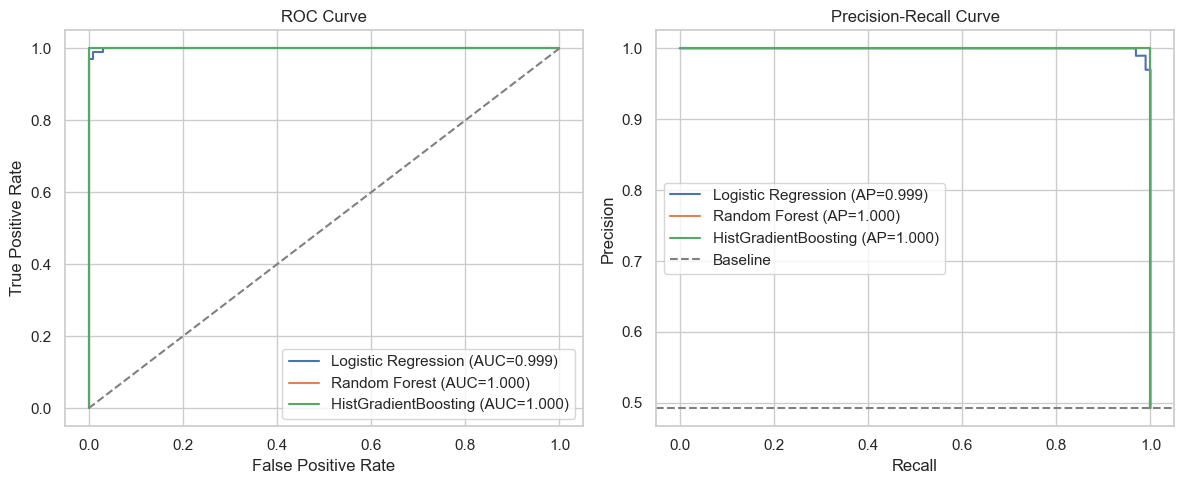

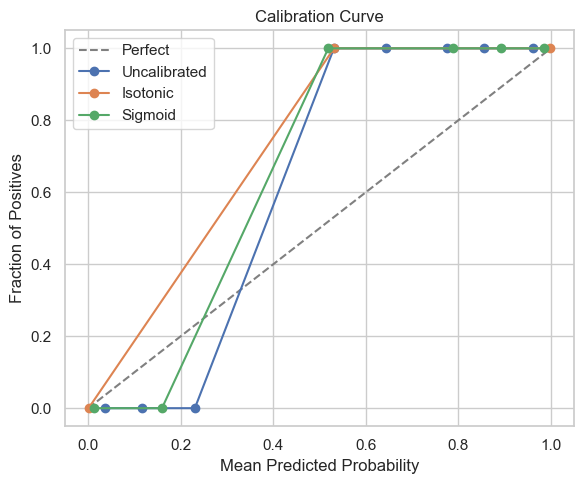

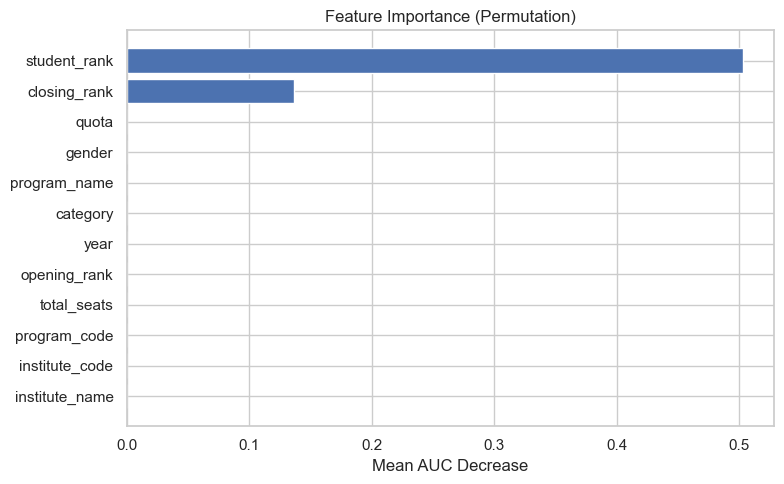

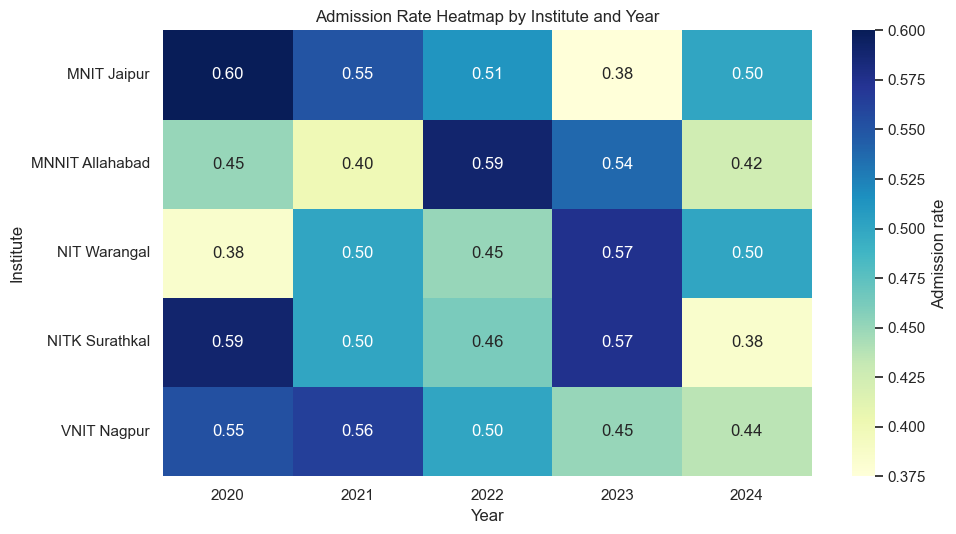

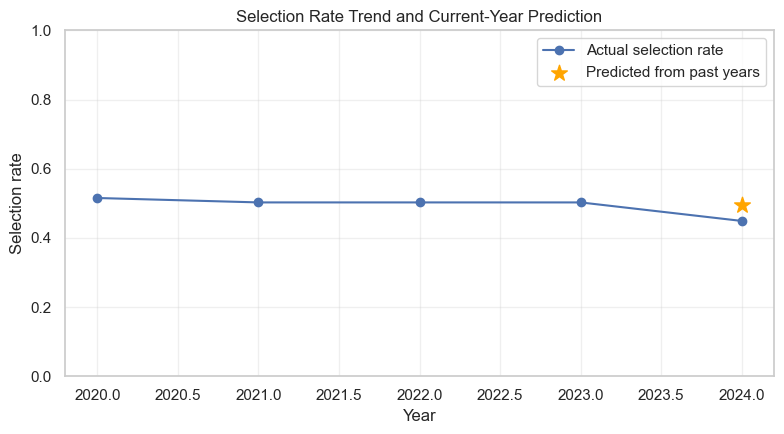

In [17]:
test_probas = {
    "Logistic Regression": lr_pipeline.predict_proba(X_test)[:, 1],
    "Random Forest": best_rf.predict_proba(X_test)[:, 1],
    "HistGradientBoosting": best_hgb.predict_proba(X_test)[:, 1],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, probs in test_probas.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for name, probs in test_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")

baseline = y_test.mean()
axes[1].axhline(baseline, color="gray", linestyle="--", label="Baseline")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
for label, model in [
    ("Uncalibrated", best_model),
    ("Isotonic", calib_isotonic),
    ("Sigmoid", calib_sigmoid),
 ]:
    probs = model.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker="o", label=label)

ax.set_title("Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend()
plt.tight_layout()
plt.show()

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=5, random_state=SEED, scoring="roc_auc"
 )
importances = pd.Series(perm.importances_mean, index=X_test.columns)
top_imp = importances.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_imp.index[::-1], top_imp.values[::-1])
ax.set_title("Feature Importance (Permutation)")
ax.set_xlabel("Mean AUC Decrease")
plt.tight_layout()
plt.show()

rate_by_inst_year = (
    df.groupby(["institute_name", "year"])[TARGET_COLUMN]
      .mean()
      .reset_index()
 )
pivot_rates = rate_by_inst_year.pivot(index="institute_name", columns="year", values=TARGET_COLUMN)
pivot_rates = pivot_rates.sort_index()

fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(pivot_rates)))
sns.heatmap(
    pivot_rates,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Admission rate"},
    ax=ax
 )
ax.set_title("Admission Rate Heatmap by Institute and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Institute")
plt.tight_layout()
plt.show()

year_rates = df.groupby("year")[TARGET_COLUMN].mean().sort_index()
years = year_rates.index.to_numpy()
rates = year_rates.values
current_year = int(years.max())
past_mask = years < current_year

if past_mask.sum() >= 2:
    coeffs = np.polyfit(years[past_mask], rates[past_mask], deg=1)
    pred_current = float(np.polyval(coeffs, current_year))
elif past_mask.sum() == 1:
    pred_current = float(rates[past_mask][0])
else:
    pred_current = float(rates.mean())

pred_current = float(np.clip(pred_current, 0, 1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(years, rates, marker="o", label="Actual selection rate")
ax.scatter([current_year], [pred_current], color="orange", marker="*", s=140, label="Predicted from past years")
ax.set_title("Selection Rate Trend and Current-Year Prediction")
ax.set_xlabel("Year")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Final Model Selection

In [18]:
print("Final model selection summary:")
print(f"Base model: {best_model_name}")
print(f"Calibrated choice: {final_name}")

print("\nCalibration results (sorted by Brier score):")
display(calib_results.reset_index(drop=True))

print("\nCross-validation summary (sorted by ROC-AUC):")
display(cv_summary.reset_index(drop=True))

print("\nPipeline is ready for production deployment.")

Final model selection summary:
Base model: Random Forest
Calibrated choice: Random Forest + isotonic

Calibration results (sorted by Brier score):


,model,roc_auc,avg_precision,brier
0,Random Forest + isotonic,1.0,1.0,0.001174
1,Random Forest + sigmoid,1.0,1.0,0.001936
2,Random Forest (uncalibrated),1.0,1.0,0.007857



Cross-validation summary (sorted by ROC-AUC):


,model,roc_auc_mean,roc_auc_std,avg_precision_mean,brier_mean
0,Random Forest,1.000000,0.000000,1.000000,0.009627
1,HistGradientBoosting,1.000000,0.000000,1.000000,0.000424
2,Logistic Regression,0.999419,0.000299,0.999424,0.021710



Pipeline is ready for production deployment.


In [ ]:
# Example rank input -> prediction graph
user_rank = 600  # change this value to test different ranks

if not isinstance(user_rank, (int, np.integer)) or user_rank <= 0:
    raise ValueError("user_rank must be a positive integer")

ref_year = int(df["year"].max())
ref_rows = df[df["year"] == ref_year].copy()
if ref_rows.empty:
    ref_rows = (
        df.sort_values("year")
          .groupby(["institute_name", "program_name", "category"], as_index=False)
          .tail(1)
          .copy()
    )
else:
    ref_rows = ref_rows.drop_duplicates(
        subset=["institute_name", "program_name", "category"]
    ).copy()

ref_rows["student_rank"] = user_rank
X_query = ref_rows[FEATURE_COLUMNS]
probs = final_model.predict_proba(X_query)[:, 1]

out = ref_rows[[
    "institute_name", "program_name", "category",
    "opening_rank", "closing_rank", "total_seats", "year"
]].copy()
out["probability"] = probs
out = out.sort_values("probability", ascending=False).reset_index(drop=True)

display(out.head(10))

top_n = min(15, len(out))
plot_df = out.head(top_n)
labels = [
    f"{r['institute_name']} | {r['program_name']} | {r['category']}"
    for _, r in plot_df.iterrows()
 ]
values = plot_df["probability"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 0.35 * top_n + 2))
ax.barh(labels[::-1], values[::-1], color="steelblue")
ax.set_xlim(0, 1)
ax.set_xlabel("Predicted admission probability")
ax.set_title(f"Predictions for rank {user_rank} (year {ref_year})")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()